1. Welcome, In this project of mine I will perform Image Segemenation on Mitochondria cells.
2. First I will load all the cell images and their masks from directories.
3. Then I will going to create Custom Data Generator which will provide batched data to our Tensorflow Custom UNet Model.
4. I will create Custom UNet model with Tensorflow that is capable of predicting masks of input cell image.
5. For Loss function, I will use Custom loss function inspired from Jacquard Coefficient.
6. Then I will train model for few epochs which simultaneously validated and will be supported by EarlyStopping, ReduceLROnPlateau and ModelCheckpoint callbacks.
7. After we are done with model training, I will create post-processing pipeline to validate our model on validation images to check for quality of predicted masks.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import imageio

import os
import random

import tifffile

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import concatenate, Conv2D, Conv2DTranspose, Dropout, Input, MaxPool2D, Flatten
from keras.optimizers import Adam
from keras import backend as K
from keras.models import Model
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [2]:
class PATH:
    train_path = "/kaggle/input/datasets/swarajsolanke/mitochondria/training.tif"
    trainGT_path = "/kaggle/input/datasets/swarajsolanke/mitochondria/training_groundtruth.tif"
    test_path = "/kaggle/input/datasets/swarajsolanke/mitochondria/testing.tif"
    testGT_path = "/kaggle/input/datasets/swarajsolanke/mitochondria/testing_groundtruth.tif"

    train_imgs = "/kaggle/working/new/train/img/"
    train_masks = "/kaggle/working/new/train/mask/"
    test_imgs = "/kaggle/working/new/test/img/"
    test_masks = "/kaggle/working/new/test/mask/"

In [3]:
# Patch_size should be factor of 1024
patch = 256

In [4]:
def img_to_dir(imgpath, maskpath, subset = 'train', patch_size = 256):
    img_ = tifffile.imread(imgpath)
    img_shape = img_.shape
    print(img_shape)
    
    mask_ = tifffile.imread(maskpath)
    patch = patch_size
    n = 1
    
    if not os.path.exists('./new/' + subset + '/'):
        if not os.path.exists("./new"):
            os.mkdir("./new/")
        os.mkdir('./new/' + subset)
        os.mkdir('./new/' + subset + '/img')
        os.mkdir('./new/' + subset + '/mask')
        
        for img, mask in zip(img_, mask_):
            for height in range(0, img_shape[1], patch):
                for width in range(0, img_shape[2], patch):
                
                    img_patch = img[height : height+patch, width : width+patch]
                    mask_patch = mask[height : height+patch, width : width+patch]
                    img_dir = './new/' + subset + '/img/' + subset + '_img_' + str(n) + '.jpg'
                    mask_dir = './new/' + subset + '/mask/' + subset + '_mask_' + str(n) + '.jpg'
                    imageio.imwrite(img_dir, img_patch)
                    imageio.imwrite(mask_dir, mask_patch)
                    n+=1

In [5]:
img_to_dir(imgpath = PATH.train_path,
           maskpath = PATH.trainGT_path,
           subset = 'train', 
            patch = patch)

img_to_dir(imgpath = PATH.test_path,
           maskpath = PATH.testGT_path,
           subset = 'test',
          patch = patch)

(165, 768, 1024)
(165, 768, 1024)


In [6]:
train_img = sorted([PATH.train_imgs + i for i in os.listdir(PATH.train_imgs)])
train_mask = sorted([PATH.train_masks + i for i in os.listdir(PATH.train_masks)])
test_img = sorted([PATH.test_imgs+ i for i in os.listdir(PATH.test_imgs)])
test_mask = sorted([PATH.test_masks+ i for i in os.listdir(PATH.test_masks)])

In [7]:
train_df = pd.DataFrame({'img_path': train_img,
                        'mask_path': train_mask})

test_df = pd.DataFrame({'img_path': test_img,
                        'mask_path': test_mask})

(256, 256)


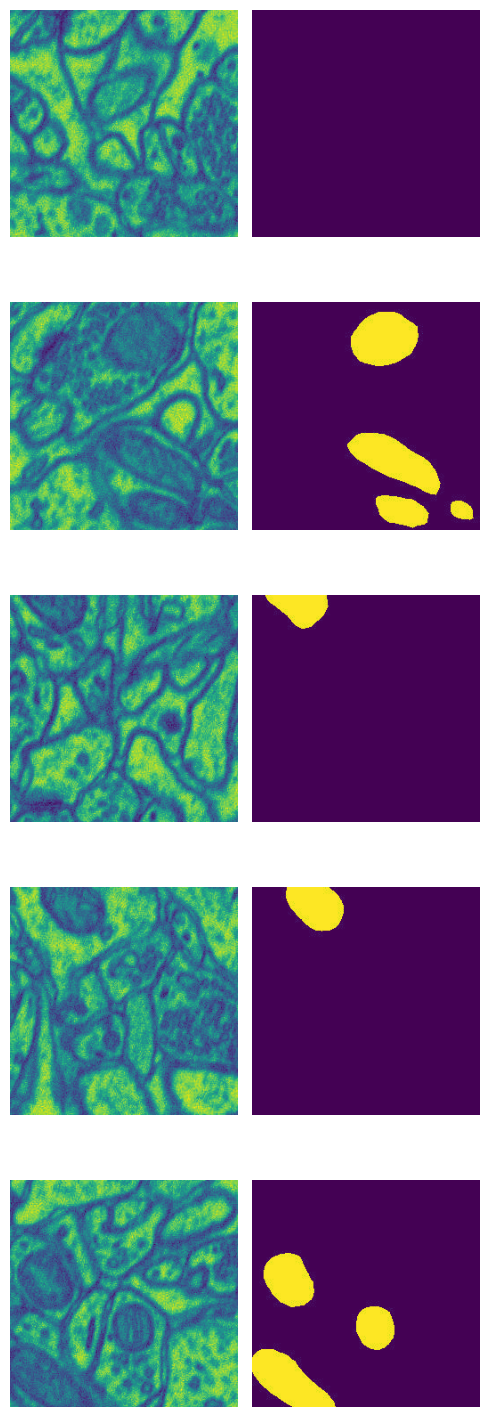

In [8]:
def printRandomImages(N=5):
    rnd = random.sample(list(range(len(train_df))), N)
    fig, ax = plt.subplots(N, 2, figsize = (N*1, N*3), tight_layout = True)
    for _ in range(N):
        img = plt.imread(train_df["img_path"].iloc[rnd[_]])
        mask = plt.imread(train_df["mask_path"].iloc[rnd[_]])
        if not _: print(img.shape)
        ax[_, 0].imshow(img)
        ax[_, 0].axis("off")
        ax[_, 1].imshow(mask)
        ax[_, 1].axis("off")
        
    plt.show()
    
printRandomImages()

In [90]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=4, shuffle=True, patch=256):
        self.df = df
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.patch = patch
        self.channels = 1
        self.data_len = len(self.df)
        self.on_epoch_end()

    def on_epoch_end(self):
        self.indexes = list(range(len(self.df)))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(self.data_len / self.batch_size))

    def __getitem__(self, index):
        FIRST, LAST = index * self.batch_size, min((index+1) * self.batch_size, self.data_len)
        X = np.empty((LAST-FIRST, self.patch, self.patch, self.channels))
        y = np.empty((LAST-FIRST, self.patch, self.patch, self.channels))
        
        batch = self.indexes[FIRST:LAST]

        for _, idx in enumerate(batch): 
            X[_], y[_] = self.getDataFromIndex(idx)

        return X, y

    def getDataFromIndex(self, idx):
        img_path = self.df["img_path"].iloc[idx]
        mask_path = self.df["mask_path"].iloc[idx]

        return (
            imageio.imread(img_path).reshape(self.patch, self.patch, 1)/255,
            imageio.imread(mask_path).reshape(self.patch, self.patch, 1)/255
        )

In [91]:
batch_size = 30
train_dg = DataGenerator(train_df, batch_size=batch_size)
valid_dg = DataGenerator(test_df, batch_size=batch_size, shuffle = False)

In [98]:
def jacard_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.reshape(y_true, (-1, 1))
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred_f = tf.reshape(y_pred, (-1, 1))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / ((tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)) - (intersection + 1.0))


def jacard_coef_loss(y_true, y_pred):
    return -jacard_coef(y_true, y_pred)

In [142]:
def getModel():
    height, width, channel = 256, 256, 1
    input_ = Input((height, width, channel), name = 'image')
    
    c1 = Conv2D(filters = 16, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(input_)
    c1 = Dropout(.1)(c1)
    c1 = Conv2D(filters = 16, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(c1)
    p1 = MaxPool2D(pool_size = 2)(c1)
    
    c2 = Conv2D(filters = 32, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(p1)
    c2 = Dropout(.1)(c2)
    c2 = Conv2D(filters = 32, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(c2)
    p2 = MaxPool2D(pool_size = 2)(c2)
    
    c3 = Conv2D(filters = 64, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(p2)
    c3 = Dropout(.1)(c3)
    c3 = Conv2D(filters = 64, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(c3)
    p3 = MaxPool2D(pool_size = 2)(c3)
    
    c4 = Conv2D(filters = 128, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(p3)
    c4 = Dropout(.1)(c4)
    c4 = Conv2D(filters = 128, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(c4)
    p4 = MaxPool2D(pool_size = 2)(c4)
    
    c5 = Conv2D(filters = 256, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(p4)
    c5 = Dropout(.3)(c5)
    c5 = Conv2D(filters = 256, kernel_size = 3,strides = 1, padding = 'same', activation = 'relu')(c5)
    
    u6 = Conv2DTranspose(filters = 128, kernel_size = 2, strides = 2)(c5)
    c6 = concatenate([u6, c4])
    c6 = Conv2D(filters = 128, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c6)
    c6 = Dropout(.1)(c6)
    c6 = Conv2D(filters = 128, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c6)
    
    u7 = Conv2DTranspose(filters = 64, kernel_size = 2, strides = 2)(c6)
    c7 = concatenate([u7, c3])
    c7 = Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c7)
    c7 = Dropout(.1)(c7)
    c7 = Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c7)
    
    u8 = Conv2DTranspose(filters = 32, kernel_size = 2, strides = 2)(c7)
    c8 = concatenate([u8, c2])
    c8 = Conv2D(filters = 32, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c8)
    c8 = Dropout(.1)(c8)
    c8 = Conv2D(filters = 32, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c8)
    
    u9 = Conv2DTranspose(filters = 16, kernel_size = 2, strides = 2)(c8)
    c9 = concatenate([u9, c1])
    c9 = Conv2D(filters = 16, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c9)
    c9 = Dropout(.1)(c9)
    c9 = Conv2D(filters = 16, kernel_size = 3, strides = 1, padding = 'same', activation = 'relu')(c9)
    
    output = Conv2D(filters = 1, kernel_size = 1, activation = 'sigmoid', name = "mask")(c9)
    
    return Model(inputs = input_, outputs = output)

In [143]:
model = getModel()
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_342 (Conv2D) │ (None, 256, 256,  │        160 │ image[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_171         │ (None, 256, 256,  │          0 │ conv2d_342[0][0]  │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_343 (Conv2D) │ (None, 256, 256,  │      2,320 │ dropout_171[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_76    │ (None, 128, 128,  │          0 │ conv2d_343[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_344 (Conv2D) │ (None, 128, 128,  │      4,640 │ max_pooling2d_76… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_172         │ (None, 128, 128,  │          0 │ conv2d_344[0][0]  │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_345 (Conv2D) │ (None, 128, 128,  │      9,248 │ dropout_172[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_77    │ (None, 64, 64,    │          0 │ conv2d_345[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_346 (Conv2D) │ (None, 64, 64,    │     18,496 │ max_pooling2d_77… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_173         │ (None, 64, 64,    │          0 │ conv2d_346[0][0]  │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_347 (Conv2D) │ (None, 64, 64,    │     36,928 │ dropout_173[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_78    │ (None, 32, 32,    │          0 │ conv2d_347[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_348 (Conv2D) │ (None, 32, 32,    │     73,856 │ max_pooling2d_78… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_174         │ (None, 32, 32,    │          0 │ conv2d_348[0][0]  │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_349 (Conv2D) │ (None, 32, 32,    │    147,584 │ dropout_174[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_79    │ (None, 16, 16,    │          0 │ conv2d_349[0][0]

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [144]:
ckpt = ModelCheckpoint(filepath = './model.weights.h5',
                       monitor = 'val_jacard_coef',
                      save_best_only = True,
                       save_weights_only=True)

In [147]:
callbacks = [
    EarlyStopping(monitor = "val_jacard_coef", patience = 5, min_delta = .001, restore_best_weights = True, mode="max"),
    ReduceLROnPlateau(monitor = "val_jacard_coef", patience = 2, factor = .5, min_lr = .000001, min_delta = .001, mode="max")
]

In [148]:
model.compile(loss = {'mask' : jacard_coef_loss},
              optimizer = Adam(learning_rate = .0009),
              metrics = {'mask' : jacard_coef})

In [149]:
model.fit(train_dg,
          epochs = 20,
          validation_data = valid_dg,
          callbacks = callbacks
          )

Epoch 1/20


/tmp/ipykernel_58/2064377553.py:36: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(img_path).reshape(self.patch, self.patch, 1)/255,
/tmp/ipykernel_58/2064377553.py:37: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(mask_path).reshape(self.patch, self.patch, 1)/255


66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - jacard_coef: 0.0620 - loss: -0.0620 - val_jacard_coef: 0.1900 - val_loss: -0.1900 - learning_rate: 9.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - jacard_coef: 0.3820 - loss: -0.3820 - val_jacard_coef: 0.4424 - val_loss: -0.4424 - learning_rate: 9.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - jacard_coef: 0.5665 - loss: -0.5665 - val_jacard_coef: 0.5156 - val_loss: -0.5156 - learning_rate: 9.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - jacard_coef: 0.6748 - loss: -0.6748 - val_jacard_coef: 0.6493 - val_loss: -0.6493 - learning_rate: 9.0000e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - jacard_coef: 0.7355 - loss: -0.7355 - val_jacard_coef: 0.6415 - val_loss: -0.6415 - learning_rate: 9.0000e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - jacard_coef: 0.7951 - loss: -0.7951 - val_jacard_coef: 0.7024 - val_loss: -0.7024 - learning_rate: 9.0000e-04
Epoch 7/20
66/66 ━━━━

In [150]:
predictions = model.predict(valid_dg)

/tmp/ipykernel_58/2064377553.py:36: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(img_path).reshape(self.patch, self.patch, 1)/255,
/tmp/ipykernel_58/2064377553.py:37: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.imread(mask_path).reshape(self.patch, self.patch, 1)/255


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step


/tmp/ipykernel_58/1046605090.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(test_df["img_path"].iloc[idx])
/tmp/ipykernel_58/1046605090.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  tru_mask = imageio.imread(test_df["mask_path"].iloc[idx])


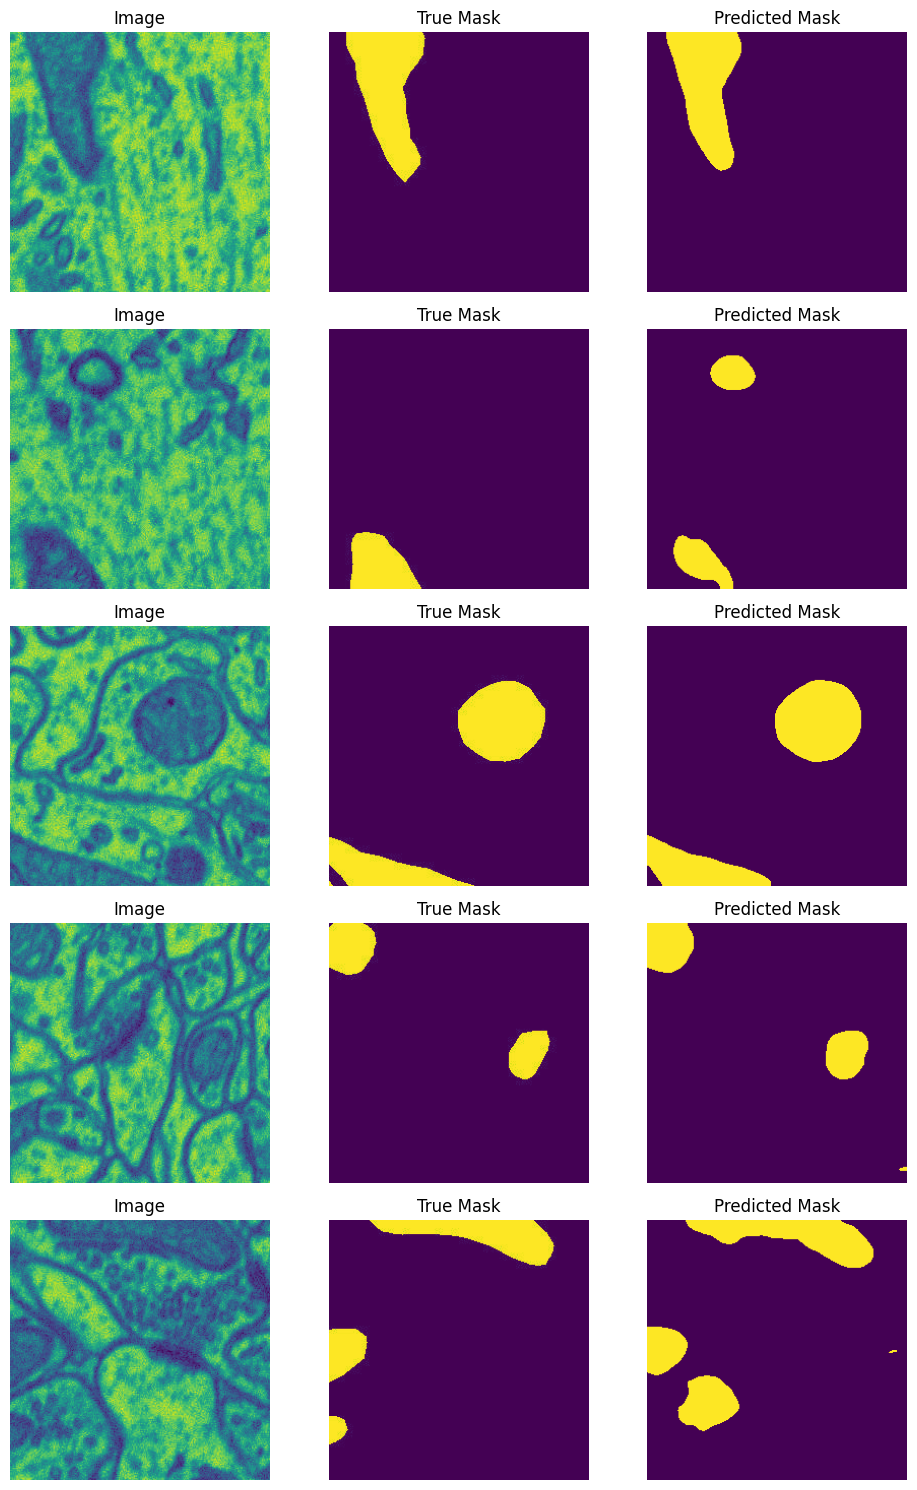

In [153]:
def predictOnValidImages(predictions,thresh=.5, N=5, patch=256):
    rnd = random.sample(list(range(len(predictions)-1)), N)
    fig, ax = plt.subplots(N, 3, figsize = (N*2, N*3), tight_layout=True)

    for _, idx in enumerate(rnd):
        img = imageio.imread(test_df["img_path"].iloc[idx])
        tru_mask = imageio.imread(test_df["mask_path"].iloc[idx])
        pred_mask = predictions[idx].reshape(patch, patch,)>=thresh
        ax[_, 0].imshow(img)
        ax[_, 0].axis("off")
        ax[_, 0].set_title("Image")

        ax[_, 1].imshow(tru_mask)
        ax[_, 1].axis("off")
        ax[_, 1].set_title("True Mask") 

        ax[_, 2].imshow(pred_mask)
        ax[_, 2].axis("off")
        ax[_, 2].set_title("Predicted Mask")

    plt.show() 

predictOnValidImages(predictions, thresh=.5)